# MLP Binary Classification for Network Traffic Analysis

This notebook implements a Multi-Layer Perceptron (MLP) for binary classification of network traffic data. It trains on the baseline dataset and evaluates performance across three key datasets:

1. **FLATTEN-PCAPS** - Baseline dataset (original traffic)
2. **MANIPULATED-FLATTEN_42** - Traffic with manipulation techniques applied
3. **FRAGMENTED_42_150** - Traffic with fragmentation techniques applied

The analysis focuses on comparing False Negative Rates (FNR) per attack type to understand model robustness against evasion techniques.

In [30]:
## 1. Import Libraries

import time
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from util_functions import load_dataset

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("✅ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully
TensorFlow version: 2.20.0


## 2. Configuration and Dataset Paths

In [31]:
# Configuration
EPOCHS = 100
BATCH_SIZE = 1024
LEARNING_RATE = 0.001

# Dataset paths
TRAFFIC_MANIPULATOR_BASE = '../TrafficManipulator-master/DATASETS/'

# Target datasets for comparison
TARGET_DATASETS = {
    'FLATTEN-PCAPS': {
        'name': 'Baseline',
        'description': 'Original traffic data (baseline)',
        'path': TRAFFIC_MANIPULATOR_BASE + 'FLATTEN-PCAPS/'
    },
    'MANIPULATED-FLATTEN_42': {
        'name': 'Manipulated',
        'description': 'Traffic with manipulation techniques (seed 42)',
        'path': TRAFFIC_MANIPULATOR_BASE + 'MANIPULATED-FLATTEN_42/'
    },
    'FRAGMENTED_42_150': {
        'name': 'Fragmented', 
        'description': 'Traffic with fragmentation techniques (seed 42, 150 fragments)',
        'path': TRAFFIC_MANIPULATOR_BASE + 'FRAGMENTED_42_150/'
    }
}

# Attack types for detailed analysis
ATTACK_TYPES = [
    '00-WebDDoS', '01-LDAP', '02-Portmap', '03-DNS', '04-UDPLag', 
    '05-NTP', '06-SNMP', '07-SSDP', '08-Syn', '09-TFTP', 
    '10-UDP', '11-NetBIOS', '12-MSSQL'
]

print("📋 Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Target Datasets: {len(TARGET_DATASETS)}")
print(f"   Attack Types: {len(ATTACK_TYPES)}")

# Verify dataset paths
print("\n📁 Dataset Path Verification:")
for key, dataset in TARGET_DATASETS.items():
    path_exists = os.path.exists(dataset['path'])
    status = "✅" if path_exists else "❌"
    print(f"   {status} {dataset['name']}: {dataset['path']}")

📋 Configuration:
   Epochs: 100
   Batch Size: 1024
   Learning Rate: 0.001
   Target Datasets: 3
   Attack Types: 13

📁 Dataset Path Verification:
   ✅ Baseline: ../TrafficManipulator-master/DATASETS/FLATTEN-PCAPS/
   ✅ Manipulated: ../TrafficManipulator-master/DATASETS/MANIPULATED-FLATTEN_42/
   ✅ Fragmented: ../TrafficManipulator-master/DATASETS/FRAGMENTED_42_150/


## 3. Load Training Data

In [32]:
# Load baseline training and validation data
baseline_path = TARGET_DATASETS['FLATTEN-PCAPS']['path']

print("📊 Loading training data...")
X_train, y_train = load_dataset(baseline_path + '*-train.hdf5')
X_val, y_val = load_dataset(baseline_path + '*-val.hdf5')

print(f"✅ Training data loaded successfully:")
print(f"   Training set: {X_train.shape} samples, {y_train.shape} labels")
print(f"   Validation set: {X_val.shape} samples, {y_val.shape} labels")
print(f"   Features per sample: {X_train.shape[1]}")

# Check class distribution
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)

print(f"\n📈 Class Distribution:")
print(f"   Training - Benign: {counts_train[0]}, Malicious: {counts_train[1]}")
print(f"   Validation - Benign: {counts_val[0]}, Malicious: {counts_val[1]}")
print(f"   Training Balance: {counts_train[1]/(counts_train[0]+counts_train[1])*100:.1f}% malicious")

📊 Loading training data...
✅ Training data loaded successfully:
   Training set: (663222, 21) samples, (663222,) labels
   Validation set: (73701, 21) samples, (73701,) labels
   Features per sample: 21

📈 Class Distribution:
   Training - Benign: 331723, Malicious: 331499
   Validation - Benign: 36679, Malicious: 37022
   Training Balance: 50.0% malicious
✅ Training data loaded successfully:
   Training set: (663222, 21) samples, (663222,) labels
   Validation set: (73701, 21) samples, (73701,) labels
   Features per sample: 21

📈 Class Distribution:
   Training - Benign: 331723, Malicious: 331499
   Validation - Benign: 36679, Malicious: 37022
   Training Balance: 50.0% malicious


In [33]:
## 4. Build and Train MLP Model

In [34]:
# Build MLP model
def build_mlp_model(input_shape, learning_rate=LEARNING_RATE):
    """Build and compile MLP model"""
    model = Sequential([
        Input(shape=(input_shape,)),
        Dense(128, activation='relu', name='dense1'),
        Dense(64, activation='relu', name='dense2'), 
        Dense(32, activation='relu', name='dense3'),
        Dense(1, activation='sigmoid', name='output')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build model
print("🏗️  Building MLP model...")
mlp_model = build_mlp_model(X_train.shape[1])
mlp_model.summary()

# Train model
print(f"\n🚀 Training model for {EPOCHS} epochs...")
start_time = time.time()

history = mlp_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

training_time = time.time() - start_time
print(f"✅ Training completed in {training_time:.2f} seconds")
print(f"   Average time per epoch: {training_time/EPOCHS:.2f} seconds")

# Save model
model_filename = 'mlp_flatten_binary_classification.h5'
mlp_model.save(model_filename)
print(f"💾 Model saved as: {model_filename}")

🏗️  Building MLP model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training model for 100 epochs...
Epoch 1/100


648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9170 - loss: 0.2043 - val_accuracy: 0.9832 - val_loss: 0.0527
Epoch 2/100
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9170 - loss: 0.2043 - val_accuracy: 0.9832 - val_loss: 0.0527
Epoch 2/100
648/648 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9871 - loss: 0.0487 - val_accuracy: 0.9942 - val_loss: 0.0417
Epoch 3/100
648/648 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9871 - loss: 0.0487 - val_accuracy: 0.9942 - val_loss: 0.0417
Epoch 3/100
648/648 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0371 - val_accuracy: 0.9947 - val_loss: 0.0312
Epoch 4/100
648/648 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0371 - val_accuracy: 0.9947 - val_loss: 0.0312
Epoch 4/100
648/648 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9948 - loss: 0.0253 - val_accuracy: 0.9954 - val_loss: 0.0193
Epoch 5/100
648/648 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9948 - loss: 0.0253 - val_accuracy: 0.9954

✅ Training completed in 135.38 seconds
   Average time per epoch: 1.35 seconds
💾 Model saved as: mlp_flatten_binary_classification.h5


In [35]:
## 5. Training Performance Analysis

def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.set_title('Model Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    print(f"📊 Final Training Metrics:")
    print(f"   Training Accuracy: {final_train_acc:.4f}")
    print(f"   Validation Accuracy: {final_val_acc:.4f}")
    print(f"   Training Loss: {final_train_loss:.4f}")
    print(f"   Validation Loss: {final_val_loss:.4f}")

# Plot training history
plot_training_history(history)

In [39]:
## 6. Model Evaluation Functions

In [41]:
def evaluate_model(model, X_test, y_test, dataset_name, verbose=True):
    """
    Comprehensive model evaluation function
    Returns detailed metrics including F1, accuracy, TPR, TNR, FNR, FPR
    """
    # Predictions
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    
    # Calculate metrics
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    # Handle different confusion matrix sizes
    if cm.size == 4:  # 2x2 matrix (both classes present)
        tn, fp, fn, tp = cm.ravel()
    elif cm.size == 1:  # Only one class present
        if np.unique(y_test)[0] == 0:  # Only benign
            tn, fp, fn, tp = cm[0, 0], 0, 0, 0
        else:  # Only malicious
            tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
    else:
        tn = fp = fn = tp = 0
    
    # Calculate rates
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity/Recall
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    
    if verbose:
        print(f"\n📊 {dataset_name} Evaluation Results:")
        print(f"   Samples: {len(X_test)}")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   True Positive Rate (TPR/Recall): {tpr:.4f}")
        print(f"   True Negative Rate (TNR/Specificity): {tnr:.4f}")
        print(f"   False Negative Rate (FNR): {fnr:.4f}")
        print(f"   False Positive Rate (FPR): {fpr:.4f}")
        print(f"   Confusion Matrix:\n{cm}")
    
    return {
        'dataset': dataset_name,
        'samples': len(X_test),
        'f1': f1,
        'accuracy': accuracy,
        'tpr': tpr,
        'tnr': tnr,
        'fnr': fnr,
        'fpr': fpr,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'confusion_matrix': cm
    }

def load_test_dataset(dataset_path, dataset_name):
    """Load test dataset with error handling"""
    try:
        test_pattern = os.path.join(dataset_path, '*-test.hdf5')
        test_files = glob.glob(test_pattern)
        
        if not test_files:
            print(f"❌ No test files found for {dataset_name}")
            return None, None
            
        X_test, y_test = load_dataset(test_pattern)
        print(f"✅ Loaded {dataset_name}: {X_test.shape} samples")
        return X_test, y_test
        
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return None, None

print("🔧 Evaluation functions defined successfully")

🔧 Evaluation functions defined successfully


def evaluate_model(model, X_test, y_test, dataset_name, verbose=True):
    """
    Comprehensive model evaluation function
    Returns detailed metrics including F1, accuracy, TPR, TNR, FNR, FPR
    """
    # Predictions
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    
    # Calculate metrics
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    # Handle different confusion matrix sizes
    if cm.size == 4:  # 2x2 matrix (both classes present)
        tn, fp, fn, tp = cm.ravel()
    elif cm.size == 1:  # Only one class present
        if np.unique(y_test)[0] == 0:  # Only benign
            tn, fp, fn, tp = cm[0, 0], 0, 0, 0
        else:  # Only malicious
            tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
    else:
        tn = fp = fn = tp = 0
    
    # Calculate rates
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity/Recall
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    
    if verbose:
        print(f"\n📊 {dataset_name} Evaluation Results:")
        print(f"   Samples: {len(X_test)}")
        print(f"   F1 Score: {f1:.4f}")
        print(f"   Accuracy: {accuracy:.4f}")
        print(f"   True Positive Rate (TPR/Recall): {tpr:.4f}")
        print(f"   True Negative Rate (TNR/Specificity): {tnr:.4f}")
        print(f"   False Negative Rate (FNR): {fnr:.4f}")
        print(f"   False Positive Rate (FPR): {fpr:.4f}")
        print(f"   Confusion Matrix:\n{cm}")
    
    return {
        'dataset': dataset_name,
        'samples': len(X_test),
        'f1': f1,
        'accuracy': accuracy,
        'tpr': tpr,
        'tnr': tnr,
        'fnr': fnr,
        'fpr': fpr,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'confusion_matrix': cm
    }

def load_test_dataset(dataset_path, dataset_name):
    """Load test dataset with error handling"""
    try:
        test_pattern = os.path.join(dataset_path, '*-test.hdf5')
        test_files = glob.glob(test_pattern)
        
        if not test_files:
            print(f"❌ No test files found for {dataset_name}")
            return None, None
            
        X_test, y_test = load_dataset(test_pattern)
        print(f"✅ Loaded {dataset_name}: {X_test.shape} samples")
        return X_test, y_test
        
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return None, None

print("🔧 Evaluation functions defined successfully")

## 7. Comprehensive Dataset Evaluation

Evaluate the trained MLP model on all three target datasets:
- **Baseline (FLATTEN-PCAPS)**: Original traffic data
- **Manipulated (MANIPULATED-FLATTEN_42)**: Traffic with manipulation techniques
- **Fragmented (FRAGMENTED_42_150)**: Traffic with fragmentation techniques

This analysis provides insights into model robustness against different evasion techniques.

In [42]:
# Load and evaluate all three target datasets
print("🎯 Comprehensive Dataset Evaluation")
print("="*60)

# Load model (in case it's not already loaded)
try:
    loaded_model = tf.keras.models.load_model('mlp_flatten_binary_classification.h5')
    print("📂 Model loaded successfully")
except:
    loaded_model = mlp_model
    print("📂 Using current model in memory")

# Storage for all results
dataset_results = {}

# Evaluate each target dataset
for dataset_key, dataset_info in TARGET_DATASETS.items():
    print(f"\n🔍 Evaluating: {dataset_info['name']} ({dataset_info['description']})")
    
    # Load test data
    X_test, y_test = load_test_dataset(dataset_info['path'], dataset_info['name'])
    
    if X_test is not None and y_test is not None:
        # Evaluate model
        results = evaluate_model(loaded_model, X_test, y_test, dataset_info['name'])
        dataset_results[dataset_key] = results
        dataset_results[dataset_key]['dataset_key'] = dataset_key
    else:
        print(f"⚠️  Skipping {dataset_info['name']} - data not available")

print(f"\n✅ Successfully evaluated {len(dataset_results)} datasets")

🎯 Comprehensive Dataset Evaluation
📂 Model loaded successfully

🔍 Evaluating: Baseline (Original traffic data (baseline))
✅ Loaded Baseline: (81887, 21) samples

📊 Baseline Evaluation Results:
   Samples: 81887
   F1 Score: 0.9992
   Accuracy: 0.9992
   True Positive Rate (TPR/Recall): 0.9987
   True Negative Rate (TNR/Specificity): 0.9997
   False Negative Rate (FNR): 0.0013
   False Positive Rate (FPR): 0.0003
   Confusion Matrix:
[[40989    14]
 [   54 40830]]

🔍 Evaluating: Manipulated (Traffic with manipulation techniques (seed 42))
✅ Loaded Manipulated: (31128, 21) samples

📊 Baseline Evaluation Results:
   Samples: 81887
   F1 Score: 0.9992
   Accuracy: 0.9992
   True Positive Rate (TPR/Recall): 0.9987
   True Negative Rate (TNR/Specificity): 0.9997
   False Negative Rate (FNR): 0.0013
   False Positive Rate (FPR): 0.0003
   Confusion Matrix:
[[40989    14]
 [   54 40830]]

🔍 Evaluating: Manipulated (Traffic with manipulation techniques (seed 42))
✅ Loaded Manipulated: (31128, 2

## 8. Attack-Specific FNR Analysis

Analyze False Negative Rate (FNR) for each attack type across all three datasets. This helps identify:
1. Which attacks are most vulnerable to evasion techniques
2. The effectiveness of different manipulation methods per attack type
3. Model robustness patterns across attack categories

In [43]:
# Attack-specific FNR analysis
print("🎯 Attack-Specific FNR Analysis")
print("="*60)

# Storage for attack-specific results
attack_fnr_results = defaultdict(dict)
attack_evaluation_data = []

# Analyze each attack type across all datasets
for attack in ATTACK_TYPES:
    attack_name = attack.split('-', 1)[1] if '-' in attack else attack
    print(f"\n🔍 Analyzing: {attack_name}")
    
    for dataset_key, dataset_info in TARGET_DATASETS.items():
        attack_path = os.path.join(dataset_info['path'], attack)
        
        if not os.path.exists(attack_path):
            print(f"   ⚠️  {dataset_info['name']}: Attack folder not found")
            continue
        
        # Look for test files
        test_pattern = os.path.join(attack_path, '*test*.hdf5')
        test_files = glob.glob(test_pattern)
        
        if not test_files:
            print(f"   ⚠️  {dataset_info['name']}: No test files found")
            continue
            
        try:
            # Load attack-specific test data
            X_attack_test, y_attack_test = load_dataset(test_pattern)
            
            if len(X_attack_test) == 0:
                print(f"   ⚠️  {dataset_info['name']}: Empty dataset")
                continue
            
            # Evaluate model
            results = evaluate_model(loaded_model, X_attack_test, y_attack_test, 
                                   f"{attack_name} - {dataset_info['name']}", verbose=False)
            
            # Store results
            attack_fnr_results[attack_name][dataset_key] = results
            
            # Store for DataFrame
            attack_evaluation_data.append({
                'Attack': attack_name,
                'Dataset': dataset_info['name'],
                'Dataset_Key': dataset_key,
                'FNR': results['fnr'],
                'F1': results['f1'],
                'Accuracy': results['accuracy'],
                'Samples': results['samples']
            })
            
            print(f"   ✅ {dataset_info['name']}: FNR={results['fnr']:.4f}, Samples={results['samples']}")
            
        except Exception as e:
            print(f"   ❌ {dataset_info['name']}: Error - {str(e)}")

print(f"\n✅ Attack analysis completed: {len(attack_fnr_results)} attacks analyzed")

🎯 Attack-Specific FNR Analysis

🔍 Analyzing: WebDDoS
   ✅ Baseline: FNR=0.0000, Samples=41
   ✅ Manipulated: FNR=0.4909, Samples=88
   ✅ Fragmented: FNR=0.6136, Samples=1313

🔍 Analyzing: LDAP
   ✅ Baseline: FNR=0.0127, Samples=153
   ✅ Manipulated: FNR=0.0052, Samples=388
   ✅ Fragmented: FNR=0.0798, Samples=237

🔍 Analyzing: Portmap
   ✅ Baseline: FNR=0.0000, Samples=18
   ✅ Baseline: FNR=0.0127, Samples=153
   ✅ Manipulated: FNR=0.0052, Samples=388
   ✅ Fragmented: FNR=0.0798, Samples=237

🔍 Analyzing: Portmap
   ✅ Baseline: FNR=0.0000, Samples=18
   ✅ Manipulated: FNR=0.0031, Samples=7095
   ✅ Fragmented: FNR=0.1259, Samples=810

🔍 Analyzing: DNS
   ✅ Baseline: FNR=0.2432, Samples=61
   ✅ Manipulated: FNR=0.1423, Samples=506
   ✅ Manipulated: FNR=0.0031, Samples=7095
   ✅ Fragmented: FNR=0.1259, Samples=810

🔍 Analyzing: DNS
   ✅ Baseline: FNR=0.2432, Samples=61
   ✅ Manipulated: FNR=0.1423, Samples=506
   ✅ Fragmented: FNR=0.2923, Samples=147

🔍 Analyzing: UDPLag
   ✅ Baseline: FN

## 9. FNR Comparison Table and Visualization

Create comprehensive comparison table showing FNR values for each attack type across all three datasets, with performance degradation analysis.

In [50]:
# Create comprehensive FNR comparison table
if attack_evaluation_data:
    # Convert to DataFrame
    fnr_df = pd.DataFrame(attack_evaluation_data)
    
    # Create pivot table for FNR comparison
    fnr_pivot = fnr_df.pivot(index='Attack', columns='Dataset', values='FNR')
    
    # Reorder attacks according to ATTACK_TYPES order (00-WebDDoS, 01-LDAP, etc.)
    attack_order = [attack.split('-', 1)[1] if '-' in attack else attack for attack in ATTACK_TYPES]
    
    # Filter to only include attacks that exist in our data and reorder
    existing_attacks = [attack for attack in attack_order if attack in fnr_pivot.index]
    fnr_pivot_ordered = fnr_pivot.reindex(existing_attacks)
    
    # Round for better display
    fnr_pivot_ordered = fnr_pivot_ordered.round(4)
    
    print("📊 FNR COMPARISON TABLE - EXACT VALUES")
    print("=" * 70)
    print("Rows = Attacks (in folder order), Columns = Datasets")
    print("=" * 70)
    print(fnr_pivot_ordered.to_string())
    
    # Summary statistics - averages per dataset (columns)
    print(f"\n📈 SUMMARY STATISTICS:")
    
    for dataset in fnr_pivot_ordered.columns:
        dataset_avg = fnr_pivot_ordered[dataset].mean()
        print(f"   Average {dataset} FNR: {dataset_avg:.4f}")
    
    # Find highest and lowest FNR values per dataset
    print(f"\n🔍 FNR ANALYSIS:")
    
    for dataset in fnr_pivot_ordered.columns:
        max_fnr_attack = fnr_pivot_ordered[dataset].idxmax()
        min_fnr_attack = fnr_pivot_ordered[dataset].idxmin()
        max_fnr_value = fnr_pivot_ordered[dataset].max()
        min_fnr_value = fnr_pivot_ordered[dataset].min()
        
        print(f"\n   {dataset} Dataset:")
        print(f"      Highest FNR: {max_fnr_attack} ({max_fnr_value:.4f})")
        print(f"      Lowest FNR:  {min_fnr_attack} ({min_fnr_value:.4f})")

else:
    print("❌ No attack evaluation data available for comparison table")

📊 FNR COMPARISON TABLE - EXACT VALUES
Rows = Attacks (in folder order), Columns = Datasets
Dataset  Baseline  Fragmented  Manipulated
Attack                                    
WebDDoS    0.0000      0.6136       0.4909
LDAP       0.0127      0.0798       0.0052
Portmap    0.0000      0.1259       0.0031
DNS        0.2432      0.2923       0.1423
UDPLag     0.0000      0.5453       0.0272
NTP        0.0028      0.8786       0.4936
SNMP       0.0000      0.1482       0.0062
SSDP       0.0015      0.0370       0.0047
Syn        0.0000      0.9999       1.0000
TFTP       0.0000      0.9963       0.8594
UDP        0.0000      0.3182       0.0000
NetBIOS    0.0038      0.1571       0.0000
MSSQL      0.0001      0.1344       0.0000

📈 SUMMARY STATISTICS:
   Average Baseline FNR: 0.0203
   Average Fragmented FNR: 0.4097
   Average Manipulated FNR: 0.2333

🔍 FNR ANALYSIS:

   Baseline Dataset:
      Highest FNR: DNS (0.2432)
      Lowest FNR:  WebDDoS (0.0000)

   Fragmented Dataset:
      Hig

## 10. FNR Visualization and Analysis

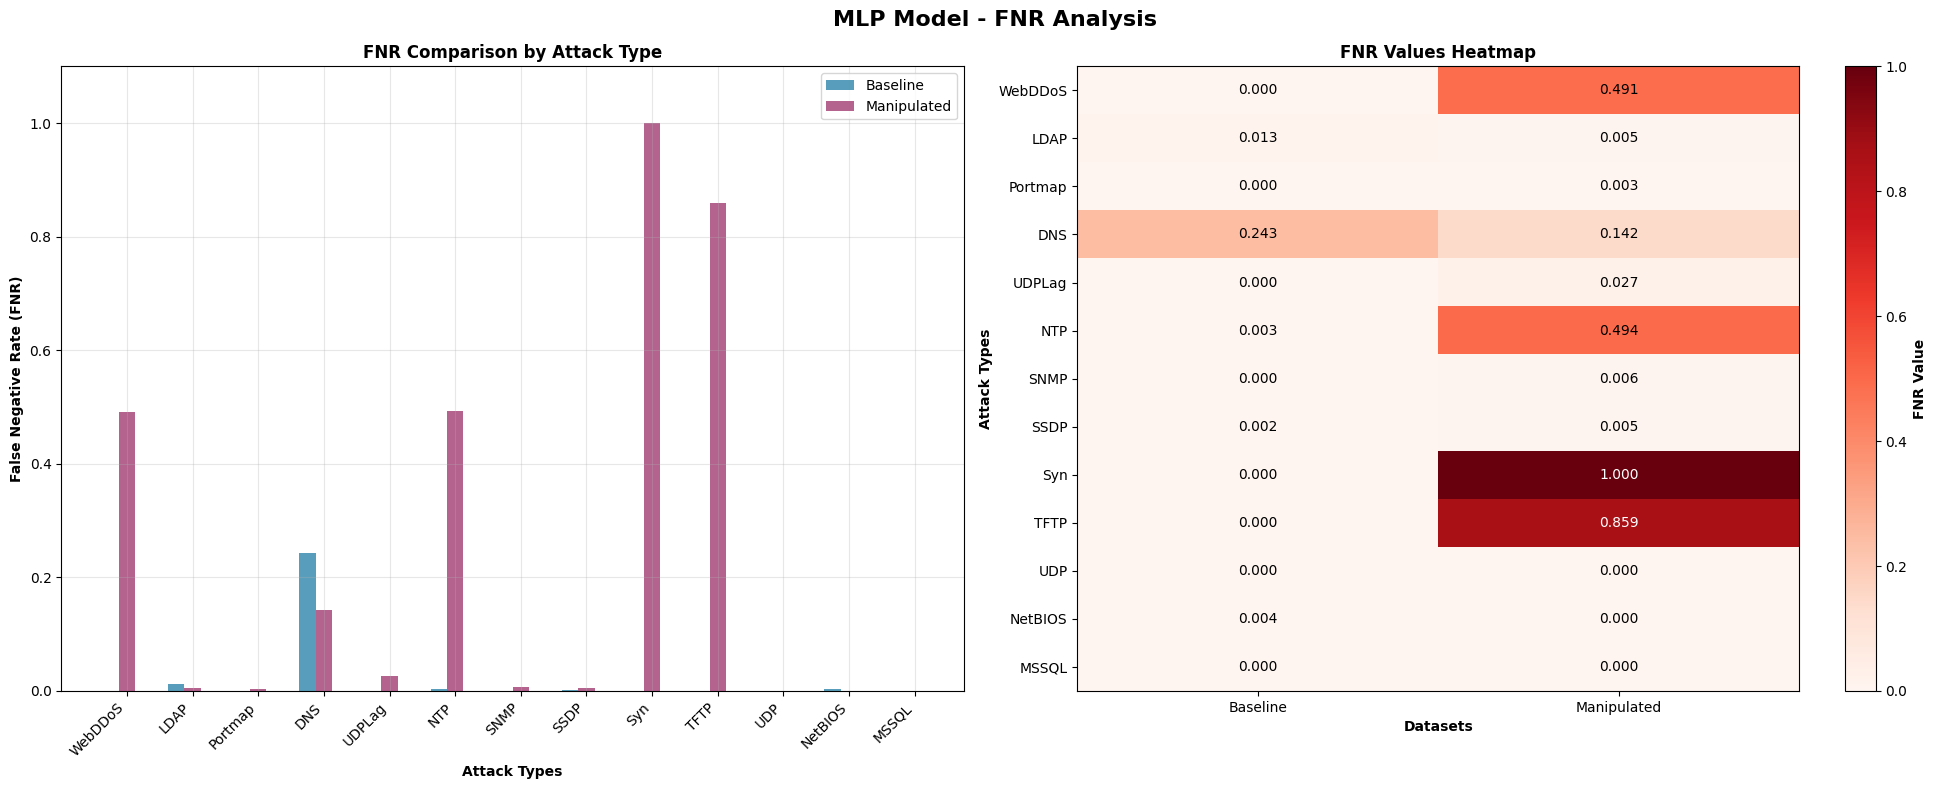


📋 CLEAN FNR COMPARISON TABLE - Attacks as Rows, Datasets as Columns
Attack Type  Baseline     Manipulated  
--------------------------------------------------------------------------------
WebDDoS      0.0000       0.4909       
LDAP         0.0127       0.0052       
Portmap      0.0000       0.0031       
DNS          0.2432       0.1423       
UDPLag       0.0000       0.0272       
NTP          0.0028       0.4936       
SNMP         0.0000       0.0062       
SSDP         0.0015       0.0047       
Syn          0.0000       1.0000       
TFTP         0.0000       0.8594       
UDP          0.0000       0.0000       
NetBIOS      0.0038       0.0000       
MSSQL        0.0001       0.0000       


In [ ]:
# Comprehensive FNR Visualization
if attack_evaluation_data and len(fnr_pivot) > 0:
    
    # Reorder attacks according to ATTACK_TYPES order
    attack_order = [attack.split('-', 1)[1] if '-' in attack else attack for attack in ATTACK_TYPES]
    existing_attacks = [attack for attack in attack_order if attack in fnr_pivot.index]
    fnr_pivot_ordered = fnr_pivot.reindex(existing_attacks)
    
    # Create visualization with only 2 plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('MLP Model - FNR Analysis', fontsize=16, fontweight='bold')
    
    # 1. FNR Comparison Bar Chart
    ax1 = axes[0]
    available_datasets = [col for col in fnr_pivot_ordered.columns if col in ['Baseline', 'Manipulated', 'Fragmented']]
    
    x = np.arange(len(fnr_pivot_ordered.index))  # Attack positions
    width = 0.25
    colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    
    for i, dataset in enumerate(available_datasets):
        values = fnr_pivot_ordered[dataset].fillna(0).values
        ax1.bar(x + i*width, values, width, label=dataset, color=colors[i % len(colors)], alpha=0.8)
    
    ax1.set_xlabel('Attack Types', fontweight='bold')
    ax1.set_ylabel('False Negative Rate (FNR)', fontweight='bold')
    ax1.set_title('FNR Comparison by Attack Type', fontweight='bold')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels(fnr_pivot_ordered.index, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max(fnr_pivot_ordered.max().max() * 1.1, 0.1))
    
    # 2. FNR Values Heatmap
    ax2 = axes[1]
    heatmap_data = fnr_pivot_ordered[available_datasets]
    im = ax2.imshow(heatmap_data.values, cmap='Reds', aspect='auto')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('FNR Value', fontweight='bold')
    
    ax2.set_title('FNR Values Heatmap', fontweight='bold')
    ax2.set_xlabel('Datasets', fontweight='bold')
    ax2.set_ylabel('Attack Types', fontweight='bold')
    ax2.set_xticks(range(len(heatmap_data.columns)))
    ax2.set_xticklabels(heatmap_data.columns, rotation=0, ha='center')
    ax2.set_yticks(range(len(heatmap_data.index)))
    ax2.set_yticklabels(heatmap_data.index)
    
    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not pd.isna(value):
                text = ax2.text(j, i, f'{value:.3f}',
                              ha="center", va="center", 
                              color="white" if value > heatmap_data.values.max()/2 else "black")
    
    plt.tight_layout()
    plt.show()
    
    # Create a clean formatted table for display
    print("\n" + "="*80)
    print("📋 CLEAN FNR COMPARISON TABLE - Attacks as Rows, Datasets as Columns")
    print("="*80)
    
    # Use the ordered data for display
    display_df = fnr_pivot_ordered[available_datasets]
    
    # Header - Dataset names
    print(f"{'Attack Type':<12} ", end="")
    for dataset in display_df.columns:
        print(f"{dataset:<12} ", end="")
    print()
    print("-" * 80)
    
    # Data rows - Each attack as a row
    for attack in display_df.index:
        print(f"{attack:<12} ", end="")
        
        for dataset in display_df.columns:
            value = display_df.loc[attack, dataset]
            if pd.isna(value):
                print(f"{'N/A':<12} ", end="")
            else:
                print(f"{value:<12.4f} ", end="")
        print()
    
else:
    print("❌ No FNR data available for visualization")